<a href="https://colab.research.google.com/github/DK8832/Coding/blob/main/2026_05_26_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#데이터 전처리
* 머신러닝 모델에 훈련데이터를 주입하기 전에 가공하는 단계
* 길이 특성보다 무게 특성에 영향을 받음
* 특성의 스케일을 맞추어야 공정하게 평가가 가능하다
* 특성을 적합하게 가능
* 방법 -> 스케일을 조정(표준점수(z점수))


In [46]:
import numpy as np

In [47]:
perch_length = np.array([8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 21.0,
       21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 22.5, 22.7,
       23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 27.3, 27.5, 27.5,
       27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 36.5, 36.0, 37.0, 37.0,
       39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 40.0, 42.0, 43.0, 43.0, 43.5,
       44.0])
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 110.0,
       115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0,
       150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0,
       218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0,
       556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0,
       850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 1000.0,
       1000.0])

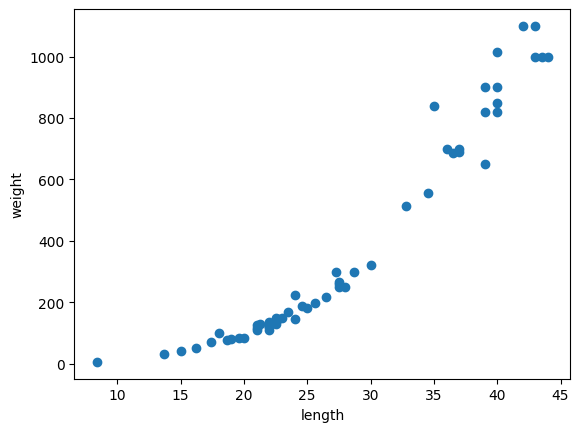

In [48]:
import matplotlib.pyplot as plt
plt.scatter(perch_length, perch_weight)
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [49]:
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(perch_length, perch_weight, random_state=42)

In [50]:
test = np.array([1, 2, 3, 4])
print(test.shape)
print(test)

(4,)
[1 2 3 4]


In [51]:
test1 = test.reshape(2, 2)
print(test1.shape)
print(test1)

(2, 2)
[[1 2]
 [3 4]]


In [52]:
test2 = test.reshape(2, -1)
print(test2.shape)
print(test2)

(2, 2)
[[1 2]
 [3 4]]


In [53]:
test3 = test.reshape(-1, 4)
print(test3.shape)
print(test3)

(1, 4)
[[1 2 3 4]]


In [54]:
train_input = train_input.reshape(-1, 1)
test_input = test_input.reshape(-1, 1)
print(train_input.shape, test_input.shape)

(42, 1) (14, 1)


In [55]:
from sklearn.neighbors import KNeighborsRegressor
knr = KNeighborsRegressor()
knr.fit(train_input, train_target)

KNeighborsRegressor()

In [56]:
knr.score(test_input, test_target)


0.992809406101064

결정계수
* 예측이 결과(타깃)에 얼마나 가까운가를 나타내는 계수
* 0~1 사이의 값
* 0에 가까울수록: 타깃이 평균정도를 예측하는 수준
* 1에 가까울수록: 예측이 타깃(실제 결과값)에 가깝다.

In [57]:
from sklearn.metrics import mean_absolute_error
test_prediction = knr.predict(test_input)
mae = mean_absolute_error(test_target, test_prediction)
print(mae)

19.157142857142862


In [58]:
knr.score(train_input, train_target)
knr.score(test_input, test_target)
print(knr.score(train_input, train_target))
print(knr.score(test_input, test_target))

0.9698823289099254
0.992809406101064


In [59]:
knr.n_neighbors = 3
knr.fit(train_input, train_target)

KNeighborsRegressor(n_neighbors=3)

In [60]:
knr.score(train_input, train_target)
knr.score(test_input, test_target)
print(knr.score(train_input, train_target))
print(knr.score(test_input, test_target))

0.9804899950518966
0.9746459963987609


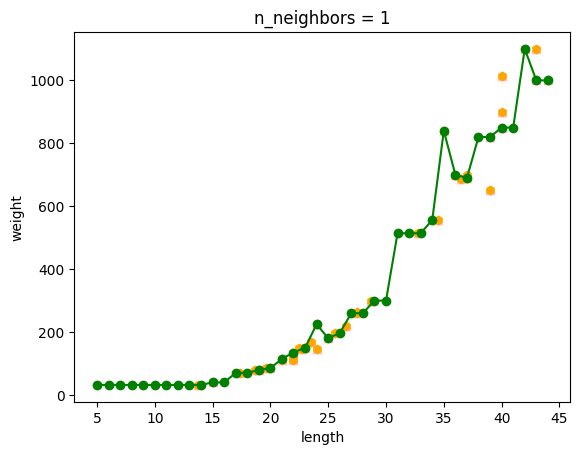

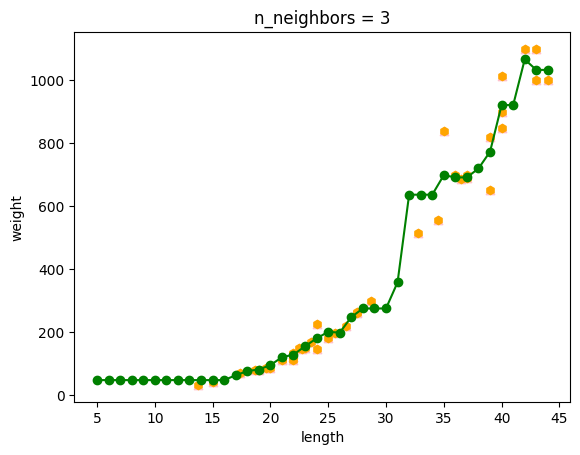

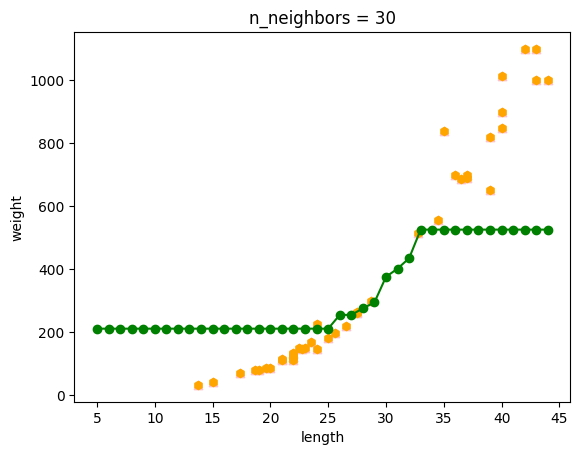

In [63]:
knr = KNeighborsRegressor( )
x = np.arange(5, 45).reshape(-1, 1)
for n in [1, 3 ,30]:
  knr.n_neighbors = n
  knr.fit(train_input, train_target)
  prediction = knr.predict(x)
  plt.scatter(train_input, train_target, color='pink', marker='^')
  plt.scatter(train_input, train_target, color='orange', marker='h')
  plt.plot(x, prediction, 'go-')
  plt.title('n_neighbors = {}'.format(n))
  plt.xlabel('length')
  plt.ylabel('weight')
  plt.show()